<a href="https://colab.research.google.com/github/shaileyj/CS175_project/blob/main/stock_and_tweet_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Preprocessing

In [23]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import pytz
from datetime import datetime
from transformers import pipeline

## Exploring Tweet Dataset

In [3]:
df = pd.read_csv('stock_tweets.csv')

In [4]:
print(df.shape)
print(df.columns)

(80793, 4)
Index(['Date', 'Tweet', 'Stock Name', 'Company Name'], dtype='str')


In [5]:
print(df['Stock Name'].value_counts())

Stock Name
TSLA    37422
TSM     11034
AAPL     5056
MSFT     4089
PG       4089
AMZN     4089
NIO      3021
META     2751
AMD      2227
NFLX     1727
GOOG     1291
PYPL      843
DIS       635
BA        399
COST      393
INTC      315
KO        310
CRM       233
XPEV      225
ENPH      216
ZS        193
VZ        123
BX         50
F          31
NOC        31
Name: count, dtype: int64


In [ ]:
to_drop = ["INTC", "KO", "CRM", "XPEV", "ENPH", "ZS", "VZ", "BX", "F", "NOC"]
new_df = df.drop(df[df['Stock Name'].isin(to_drop)].index)
print(new_df.shape)

(75505, 4)


## Dealing with Dates

In [7]:
#Figuring out how to deal with the dates in this dataset
date = datetime.fromisoformat(df['Date'][0])
print(date)
print(date.hour)
print(date.day)
print(date.month)

2022-09-29 23:41:16+00:00
23
29
9


In [8]:
stock_date_ex = '1998-01-02 16:00:00' #copied and pasted a date from the stock
                                      #dataset, we'll need to compare dates
                                      #from both sets (probably)
stock_date = datetime.fromisoformat(stock_date_ex)
print(stock_date)
print(stock_date.hour)
print(stock_date.day)
print(stock_date.month)

1998-01-02 16:00:00
16
2
1


In [9]:
utc = pytz.UTC
print(date > utc.localize(stock_date))

True


## Sentiment Analysis

In [10]:
# Load the classification pipeline with the specified model
pipe = pipeline("text-classification", model="tabularisai/multilingual-sentiment-analysis")

# Classify a new sentence
sentence = "I love this product! It's amazing and works perfectly."
result = pipe(sentence)

# Print the result
print(result[0]['label'])

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 8082.56it/s]


Very Positive


In [11]:
sentiment_to_value = {"Very Negative": -2, "Negative": -1, "Neutral": 0, "Positive": 1, "Very Positive": 2}
sentiments = pd.Series()
for i in range(len(df)):
  sentiments[i] = sentiment_to_value[pipe(df['Tweet'][i])[0]['label']]

In [12]:
df['Sentiment'] = sentiments
print(df['Sentiment'].value_counts())

Sentiment
 0    57632
-1     8239
 2     6597
 1     5274
-2     3051
Name: count, dtype: int64


Seems like there's a lot of "neutral" tweets

## Combining Stock + Sentiment Data

In [15]:
!unzip stock_data/AAPL.US_H1.csv.zip -d stock_data
aapl_df = pd.read_csv("stock_data/AAPL.US_H1.csv")

Archive:  stock_data/AAPL.US_H1.csv.zip
  inflating: stock_data/AAPL.US_H1.csv  


In [16]:
tweet_df = df

In [17]:
print(aapl_df.shape)
print(aapl_df.columns)

(46751, 6)
Index(['datetime', 'open', 'high', 'low', 'close', 'volume'], dtype='str')


In [18]:
tweet_date = datetime.fromisoformat(tweet_df["Date"][0])
print(tweet_date)
tweet_hour = datetime(tweet_date.year, tweet_date.month, tweet_date.day, tweet_date.hour)
print(tweet_hour)

sd ="2022-09-29 23:00:00"
stock_date_ex = datetime.fromisoformat(sd)
print(stock_date_ex)
print(tweet_hour == stock_date_ex)
print(tweet_hour.isoformat())

2022-09-29 23:41:16+00:00
2022-09-29 23:00:00
2022-09-29 23:00:00
True
2022-09-29T23:00:00


In [19]:
def drop_rows_not_in_tweet_range(stock_df):
  not_in_tweet_range = []
  start = datetime(2021, 9, 29, 0)
  end = datetime(2022, 9, 29, 23)
  for i in range(len(stock_df)):
    date = datetime.fromisoformat(stock_df["datetime"][i])
    if date < start or date > end:
      not_in_tweet_range.append(i)
  result = stock_df.drop(not_in_tweet_range).reset_index(drop=True)
  return result

In [20]:
def binary_search(arr, x):
    low = 0
    high = len(arr) - 1
    while low <= high:
        mid = low + (high - low) // 2
        date = datetime.fromisoformat(arr[mid])
        if date == x:
            return mid
        elif date < x:
            low = mid + 1
        else:
            high = mid - 1
    return -1

In [21]:
def add_sentiment_to_stock_df(stock_df, tweet_df):
  sentiments = pd.Series(0, index=range(len(stock_df)))
  for i in range(len(tweet_df)):
    tweet_date = datetime.fromisoformat(tweet_df["Date"][i])
    tweet_hour = datetime(tweet_date.year, tweet_date.month, tweet_date.day, tweet_date.hour)
    index = binary_search(stock_df["datetime"], tweet_hour)
    if index != -1:
      sentiments[index] += tweet_df['Sentiment'][i]
  stock_df['sentiment'] = sentiments

In [ ]:
stock_tickers = ['AAPL', 'AMD', 'AMZN', 'BA', 'COST', 'DIS', 'GOOG', 'META', 'MSFT', 'NFLX', 'PG', 'PYPL','TSLA']
stock_file_beginning = 'stock_data/'
new_beginning = 'sentiment_stock_data/'
stock_file_end = '.US_H1.csv'
os.makedirs(new_beginning, exist_ok=True)
for ticker in stock_tickers:
  file_name = stock_file_beginning + ticker + stock_file_end
  if not os.path.isfile(file_name):
    zip_name = file_name + '.zip'
    !unzip $zip_name -d $stock_file_beginning
  stock_df = pd.read_csv(file_name)
  stock_df = drop_rows_not_in_tweet_range(stock_df)
  add_sentiment_to_stock_df(stock_df, tweet_df)
  stock_df.to_csv(new_beginning + ticker + "_sentiment.csv", index=False)

Archive:  stock_data/AMD.US_H1.csv.zip
  inflating: stock_data//AMD.US_H1.csv  
Archive:  stock_data/AMZN.US_H1.csv.zip
  inflating: stock_data//AMZN.US_H1.csv  
Archive:  stock_data/BA.US_H1.csv.zip
  inflating: stock_data//BA.US_H1.csv  
Archive:  stock_data/COST.US_H1.csv.zip
  inflating: stock_data//COST.US_H1.csv  
Archive:  stock_data/DIS.US_H1.csv.zip
  inflating: stock_data//DIS.US_H1.csv  
Archive:  stock_data/GOOG.US_H1.csv.zip
  inflating: stock_data//GOOG.US_H1.csv  
Archive:  stock_data/META.US_H1.csv.zip
  inflating: stock_data//META.US_H1.csv  
Archive:  stock_data/MSFT.US_H1.csv.zip
  inflating: stock_data//MSFT.US_H1.csv  
Archive:  stock_data/NFLX.US_H1.csv.zip
  inflating: stock_data//NFLX.US_H1.csv  
Archive:  stock_data/PG.US_H1.csv.zip
  inflating: stock_data//PG.US_H1.csv  
Archive:  stock_data/PYPL.US_H1.csv.zip
  inflating: stock_data//PYPL.US_H1.csv  
Archive:  stock_data/TSLA.US_H1.csv.zip
  inflating: stock_data//TSLA.US_H1.csv  


In [27]:
tsla_df = pd.read_csv(new_beginning + "TSLA_sentiment.csv")
print(tsla_df['sentiment'].value_counts())

sentiment
 0     307
-1     236
 1     227
 2     207
-2     170
 3     141
-3     103
 4      88
-4      81
 5      78
-5      57
 6      48
-6      41
 7      36
 8      28
-7      28
 9      16
 10     15
-8      10
-9      10
 11      7
-10      7
 14      6
-12      6
 12      5
 13      5
-11      4
 16      4
-17      3
 15      2
 17      2
 20      2
-15      2
-24      2
-13      2
-14      1
 18      1
 21      1
-46      1
-18      1
-21      1
-20      1
-67      1
 19      1
-42      1
 26      1
Name: count, dtype: int64


In [28]:
tsla_df

,datetime,open,high,low,close,volume,sentiment
0,2021-09-29 16:00:00,259.93,263.51,259.70,262.83,5948430,0
1,2021-09-29 17:00:00,262.83,264.50,262.23,263.54,6937515,0
2,2021-09-29 18:00:00,263.58,263.62,259.60,260.72,6399114,0
3,2021-09-29 19:00:00,260.79,261.48,256.89,258.33,5889309,0
4,2021-09-29 20:00:00,258.34,259.58,257.15,258.35,3775977,0
...,...,...,...,...,...,...,...
1992,2022-09-29 19:00:00,272.96,273.09,268.91,269.30,6059690,4
1993,2022-09-29 20:00:00,269.32,269.35,266.57,266.86,6874062,-3
1994,2022-09-29 21:00:00,266.89,268.33,266.01,266.03,6041103,2
1995,2022-09-29 22:00:00,266.02,269.40,265.78,268.35,8610715,-17


## Risk-Free Rate Preprocessing

In [29]:
risk_free_rates = pd.read_csv("DTB3.csv")
not_in_tweet_range = []
start = datetime(2021, 9, 29)
end = datetime(2022, 9, 29)
for i in range(len(risk_free_rates)):
  date = datetime.fromisoformat(risk_free_rates["observation_date"][i])
  if date < start or date > end:
      not_in_tweet_range.append(i)
risk_free_rates = risk_free_rates.drop(not_in_tweet_range).reset_index(drop=True)
risk_free_rates = risk_free_rates.ffill() #fill empty rows with value in previous row
risk_free_rates.to_csv("risk_free_rates.csv", index=False)
risk_free_rates

,observation_date,DTB3
0,2021-09-29,0.04
1,2021-09-30,0.04
2,2021-10-01,0.04
3,2021-10-04,0.04
4,2021-10-05,0.04
...,...,...
257,2022-09-23,3.12
258,2022-09-26,3.30
259,2022-09-27,3.26
260,2022-09-28,3.29


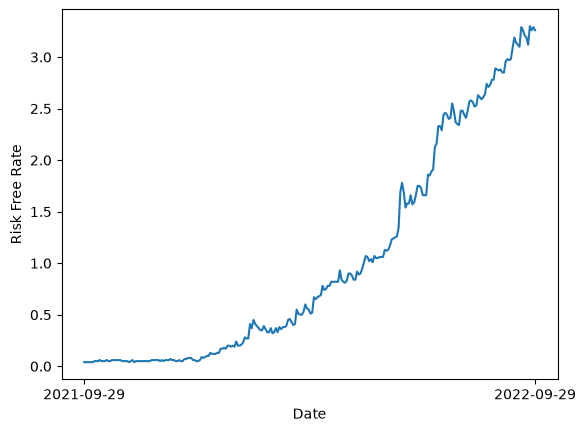

In [30]:
risk_free_rates = pd.read_csv("risk_free_rates.csv")
fig, ax = plt.subplots()
plt.plot(risk_free_rates['observation_date'], risk_free_rates['DTB3'])
plt.xlabel("Date")
plt.ylabel("Risk Free Rate")
ax.set_xticks(('2021-09-29', '2022-09-29'))
plt.show()

## Visualize Stock Data

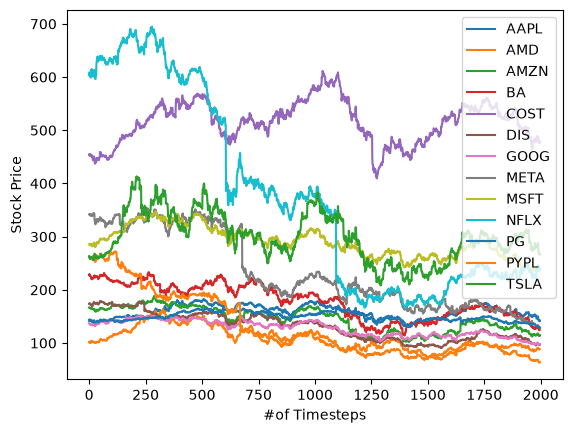

In [ ]:
plt.figure()
stock_tickers = ['AAPL', 'AMD', 'AMZN', 'BA', 'COST', 'DIS', 'GOOG', 'META', 'MSFT', 'NFLX', 'PG', 'PYPL','TSLA']
stock_file_beginning = 'sentiment_stock_data/'
stock_file_end = '_sentiment.csv'
for ticker in stock_tickers:
  stock_data = pd.read_csv(stock_file_beginning + ticker + stock_file_end)
  plt.plot(stock_data['close'], label = ticker)
plt.legend()
plt.xlabel("#of Timesteps")
plt.ylabel("Stock Price")
plt.show()